<a href="https://colab.research.google.com/github/lasyasreereddygudimetla-bit/Agile-ALM-Demo/blob/main/R23EA043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Iris Flower Classification

--- Training Models ---
Saved: logistic_regression_model.pkl
Saved: k-nn_model.pkl
Saved: random_forest_model.pkl
Saved: svm_model.pkl


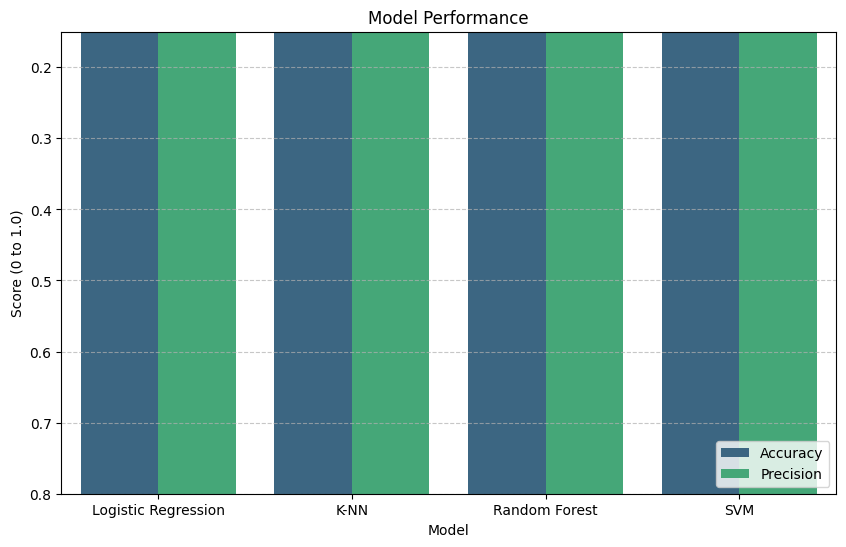

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

iris = load_iris()
X, y = iris.data, iris.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

models = {
    "Logistic Regression": LogisticRegression(),
    "K-NN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = []

print("--- Training Models ---")
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')

    results.append({"Model": name, "Metric": "Accuracy", "Score": accuracy})
    results.append({"Model": name, "Metric": "Precision", "Score": prec})

    filename = f"{name.replace(' ', '_').lower()}_model.pkl"
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Model', y='Score', hue='Metric', palette='viridis')

plt.title('Model Performance')
plt.ylim(0.8,0.15)
plt.ylabel('Score (0 to 1.0)')
plt.legend(loc='lower right')
plt.grid(axis= 'y', linestyle='--', alpha=0.7)
plt.show()